# Multi-Signal LSTM Forecast Notebook

This notebook trains `wholesale_price`, `load`, and `pv` LSTM forecasters, validates the fixed `2020-06-01` to `2020-06-07` window, and then refreshes the canonical MADRL shared-data package.

Goals:
- keep one shared config block plus per-signal overrides
- train all three canonical signals without reuse or fallback branches
- export one validation bundle for `2020-06-01` to `2020-06-07`
- regenerate the single canonical MADRL shared-data package after validation passes


In [1]:
from pathlib import Path
import json
import shutil
import sys
import uuid
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass
project_root = Path.cwd().resolve()
while project_root != project_root.parent and (not (project_root / 'configs').exists()):
    project_root = project_root.parent
if not (project_root / 'configs').exists():
    raise RuntimeError('Could not locate the project root.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root

_FORECAST_NOTEBOOK_TEST_ANCHORS = """
while project_root != project_root.parent and not (project_root / "configs").exists()
device_request = None
require_cuda = False
cfg.data.agent_profiles = ["SFH12", "SFH14", "SFH16", "SFH18", "SFH20"]
cfg.env.num_agents = len(cfg.data.agent_profiles)
auto_train_missing=False
weekly_validation_signals = ["wholesale_price", "load", "pv"]
weekly_validation_start_date = "2020-06-01"
weekly_validation_end_date = "2020-06-07"
test_window_2020-06-01_2020-06-07
wholesale_price.parquet
load.parquet
pv.parquet
ensure_madrl_shared_data
"""


In [2]:
from IPython.display import display
from predictors.training import train_signal_lstm
from predictors.mainline_forecast import get_mainline_forecast_controls
from predictors.shared_data import ensure_madrl_shared_data
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device
from configs.profiles import compose_experiment_config


## 1. Runtime and Per-Signal Settings

Keep shared settings and per-signal overrides separate so students can edit them quickly.


In [3]:
runtime_mode = 'performance'
seed = 0
device_request = None
require_cuda = False
FORECAST_CONTROLS = get_mainline_forecast_controls(
    artifact_root=project_root / 'artifacts' / 'forecast' / 'lstm',
    auto_train_missing=False,
)
signal_order = list(FORECAST_CONTROLS['target_signals'])
load_model_mode = str(FORECAST_CONTROLS['load_model_mode'])
load_time_feature_mode = str(FORECAST_CONTROLS['load_time_feature_mode'])
pv_time_feature_mode = str(FORECAST_CONTROLS['pv_time_feature_mode'])
load_hybrid_mode = str(FORECAST_CONTROLS['load_hybrid_mode'])
load_baseline_mode = str(FORECAST_CONTROLS['load_baseline_mode'])
load_component_split = bool(FORECAST_CONTROLS['load_component_split'])
load_scaler_type = str(FORECAST_CONTROLS['load_scaler_type'])
shared_settings = {
    'future_horizon': int(FORECAST_CONTROLS['future_horizon']),
    'history_window': int(FORECAST_CONTROLS['history_window']),
    'artifact_root': Path(FORECAST_CONTROLS['artifact_root']),
}
signal_training_overrides = dict(FORECAST_CONTROLS['signal_training_overrides'])
validation_root = project_root / 'artifacts' / 'forecast' / 'validation' / 'lstm' / f"h{int(FORECAST_CONTROLS['future_horizon'])}"
shared_data_root = project_root / 'artifacts' / 'training' / 'shared_data' / 'mainline'


In [ ]:
cfg = compose_experiment_config(forecast_type='lstm', data_dir=project_root / 'data', runtime_mode=runtime_mode, seed=seed, require_cuda=require_cuda)
cfg.data.agent_profiles = ['SFH12', 'SFH18', 'SFH20']
cfg.env.num_agents = len(cfg.data.agent_profiles)
cfg.data.train_year = 2019
cfg.data.test_year = 2020
cfg.data.load_components = ['household', 'heatpump']
cfg.data.pv_reference = 'south'
cfg.obs.sequence_features = list(signal_order)
cfg.forecast.target_signals = list(signal_order)
cfg.env.future_horizon = int(shared_settings['future_horizon'])
cfg.forecast.history_window = int(shared_settings['history_window'])
cfg.forecast.load_model_mode = load_model_mode
cfg.forecast.load_time_feature_mode = load_time_feature_mode
cfg.forecast.pv_time_feature_mode = pv_time_feature_mode
cfg.forecast.load_hybrid_mode = load_hybrid_mode
cfg.forecast.load_baseline_mode = load_baseline_mode
cfg.forecast.pv_postprocess_mode = 'physical_clip'
cfg.forecast.lstm_artifact_root = Path(shared_settings['artifact_root'])
cfg.forecast.auto_train_missing = bool(FORECAST_CONTROLS['auto_train_missing'])
cfg.forecast.signal_training_overrides = dict(signal_training_overrides)
cfg.forecast.load_component_split = load_component_split
cfg.forecast.load_scaler_type = load_scaler_type
runtime_state = configure_torch_runtime(cfg, device=device_request, seed=seed, require_cuda=require_cuda)
experiment_summary = {'runtime_mode': cfg.runtime.execution_mode, 'device': str(runtime_state.device), 'device_info': describe_device(runtime_state), 'num_agents': int(cfg.env.num_agents), 'agent_profiles': list(cfg.data.agent_profiles), 'train_year': int(cfg.data.train_year), 'test_year': int(cfg.data.test_year), 'future_horizon': cfg.env.future_horizon, 'history_window': cfg.forecast.history_window, 'load_model_mode': cfg.forecast.load_model_mode, 'load_time_feature_mode': cfg.forecast.load_time_feature_mode, 'pv_time_feature_mode': cfg.forecast.pv_time_feature_mode, 'pv_postprocess_mode': cfg.forecast.pv_postprocess_mode, 'artifact_root': str(cfg.forecast.lstm_artifact_root), 'load_hybrid_mode': cfg.forecast.load_hybrid_mode, 'load_baseline_mode': cfg.forecast.load_baseline_mode, 'load_component_split': cfg.forecast.load_component_split, 'load_scaler_type': cfg.forecast.load_scaler_type, 'signal_order': list(signal_order), 'signal_training_overrides': signal_training_overrides}
pprint(experiment_summary)


{'agent_profiles': ['SFH12', 'SFH14', 'SFH16', 'SFH18', 'SFH20'],
 'artifact_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm',
 'device': 'cuda:0',
 'device_info': {'capability': '12.0',
                 'cuda_available': True,
                 'device': 'cuda:0',
                 'name': 'NVIDIA GeForce RTX 5070',
                 'total_memory_gb': 11.94},
 'future_horizon': 24,
 'history_window': 288,
 'load_baseline_mode': 'last_value',
 'load_component_split': True,
 'load_hybrid_mode': 'baseline_blend',
 'load_model_mode': 'per_agent',
 'load_scaler_type': 'robust',
 'load_time_feature_mode': 'hour_week_year',
 'num_agents': 5,
 'pv_postprocess_mode': 'physical_clip',
 'pv_time_feature_mode': 'hour_week_year',
 'runtime_mode': 'performance',
 'signal_order': ['wholesale_price', 'load', 'pv'],
 'signal_training_overrides': {'load': {'batch_size': 1024,
                                        'dropout': 0.1,
                                   

## 2. Helper for Train-Then-Plot

`train_signal_lstm(..., show_progress=True)` shows an epoch progress bar for the current signal.
The helper below trains one signal and renders its charts immediately.


In [5]:
def _plot_notebook_evaluation(axis, evaluation, *, title_suffix=None):
    target = evaluation.target if evaluation.target.ndim == 1 else evaluation.target.sum(axis=0)
    prediction = evaluation.prediction if evaluation.prediction.ndim == 1 else evaluation.prediction.sum(axis=0)
    ylabel = evaluation.signal_name if evaluation.target.ndim == 1 else f"{evaluation.signal_name} (sum)"
    axis.plot(evaluation.timestamps, target, label='Ground truth', linewidth=1.5)
    axis.plot(evaluation.timestamps, prediction, label='Prediction', linewidth=1.5)
    axis.set_title(str(evaluation.signal_name) if title_suffix is None else f"{evaluation.signal_name} - {title_suffix}")
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend(loc='upper right')


def _show_training_report(result):
    rows = list(result.get('agent_results') or [result])
    figure, axes = plt.subplots(len(rows), 3, figsize=(18, 4.8 * len(rows)), squeeze=False)
    for row_idx, item in enumerate(rows):
        label = item['signal_name']
        if item.get('agent_profile') is not None:
            label = f"{label}[{item['agent_profile']}]"
        if item.get('component') is not None:
            label = f"{label}:{item['component']}"
        axes[row_idx, 0].plot(item['training']['history']['train_loss'], label='Train', linewidth=1.6)
        axes[row_idx, 0].plot(item['training']['history']['val_loss'], label='Validation', linewidth=1.6)
        axes[row_idx, 0].set_title(f"{label} - Loss")
        axes[row_idx, 0].set_xlabel('epoch')
        axes[row_idx, 0].set_ylabel('MSE')
        axes[row_idx, 0].grid(True, alpha=0.3)
        axes[row_idx, 0].legend(loc='upper right')
        if item.get('evaluation') is not None:
            _plot_notebook_evaluation(axes[row_idx, 1], item['evaluation'], title_suffix='online_aligned')
            axes[row_idx, 1].set_xlabel('timestamp')
        else:
            axes[row_idx, 1].axis('off')
        if item.get('open_loop_evaluation') is not None:
            _plot_notebook_evaluation(axes[row_idx, 2], item['open_loop_evaluation'], title_suffix='open_loop')
            axes[row_idx, 2].set_xlabel('timestamp')
        else:
            axes[row_idx, 2].axis('off')
    figure.tight_layout()
    return figure


results = {}


def train_and_report_signal(signal_name: str):
    override = dict(signal_training_overrides[signal_name])
    effective = {
        'history_window': shared_settings['history_window'],
        'future_horizon': shared_settings['future_horizon'],
        **override,
    }
    print('=' * 88)
    print(f'[{signal_name}] training starts')
    pprint(effective)
    result = train_signal_lstm(
        cfg,
        signal_name,
        device=runtime_state,
        overrides=override,
        show_progress=True,
        compute_evaluations=False,
    )
    figure = _show_training_report(result)
    plt.show()
    plt.close(figure)
    print(f"[{signal_name}] best_val_loss = {result['training']['best_val_loss']:.6f}")
    if result.get('agent_results'):
        for agent_result in result['agent_results']:
            agent_label = agent_result['signal_name']
            if agent_result.get('agent_profile') is not None:
                agent_label = f"{agent_label}[{agent_result['agent_profile']}]"
            if agent_result.get('component') is not None:
                agent_label = f"{agent_label}:{agent_result['component']}"
            print(
                f"[{signal_name}] item={agent_label} best_val_loss={agent_result['training']['best_val_loss']:.6f} "
                f"blend_weight={agent_result['hybrid']['blend_weight']} artifact_paths={agent_result['artifact_paths']}"
            )
    else:
        print(f"[{signal_name}] artifact_paths = {result['artifact_paths']}")
    return result


In [6]:
results = {}
signals_to_train = [signal_name for signal_name in signal_order if signal_name not in results]
print(f'[section 2] training signals = {signals_to_train}')
for signal_name in signals_to_train:
    results[signal_name] = train_and_report_signal(signal_name)


[section 2] training signals = ['wholesale_price', 'load', 'pv']
[wholesale_price] training starts
{'batch_size': 1024,
 'dropout': 0.1,
 'epochs': 20,
 'future_horizon': 24,
 'hidden_size': 64,
 'history_window': 288,
 'lr': 0.001,
 'num_layers': 2}


ValueError: load_scale length should equal n_agents=5, got 3

In [ ]:
artifact_map = {signal_name: results[signal_name]['artifact_paths'] for signal_name in signal_order}
final_summary = {}
for signal_name in signal_order:
    result = results[signal_name]
    summary = {
        'settings': result['settings'],
        'artifact_paths': result['artifact_paths'],
    }
    training = result.get('training')
    if training is not None:
        summary['best_val_loss'] = float(training['best_val_loss'])
    final_summary[signal_name] = summary
print('section 2 diagnostics: loss curves shown inline; fixed-window validation is deferred to section 3')
pprint(final_summary)
artifact_map


section 2 diagnostics: loss curves shown inline; fixed-window validation is deferred to section 3
{'load': {'artifact_paths': [{'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_meta.json',
                              'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household.pt',
                              'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_scaler.pkl'},
                             {'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\heatpump\\load_agent0_lstm_h24_heatpump_meta.json',
                              'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forec

{'wholesale_price': {'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\wholesale_price\\wholesale_price_lstm_h24.pt',
  'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\wholesale_price\\wholesale_price_lstm_h24_meta.json',
  'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\wholesale_price\\wholesale_price_lstm_h24_scaler.pkl'},
 'load': [{'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household.pt',
   'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_meta.json',
   'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_scaler.pkl'},

## 3. Weekly Validation Window

This section validates the fixed controller-facing window `2020-06-01` to `2020-06-07` for `wholesale_price`, `load`, and `pv`.


The cell below runs one-step rolling predictions with ideal warmup, shows weekly validation plots, and writes a one-off validation bundle under `artifacts/forecast/validation/...`.

This validation bundle is not the canonical MADRL handoff directory.


In [ ]:
weekly_validation_signals = ["wholesale_price", "load", "pv"]
weekly_validation_start_date = "2020-06-01"
weekly_validation_end_date = "2020-06-07"
weekly_validation_dir = validation_root / f"test_window_{weekly_validation_start_date}_{weekly_validation_end_date}"


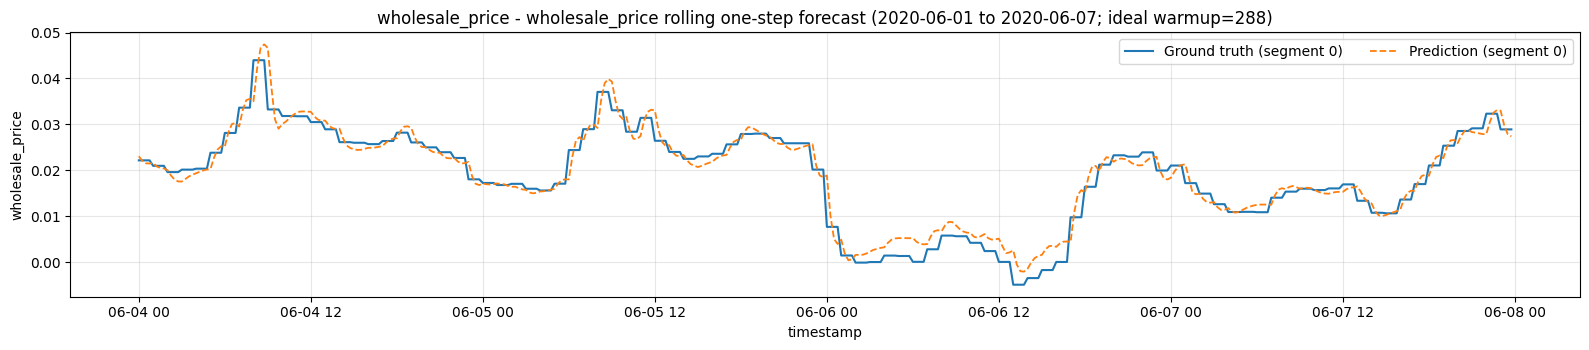

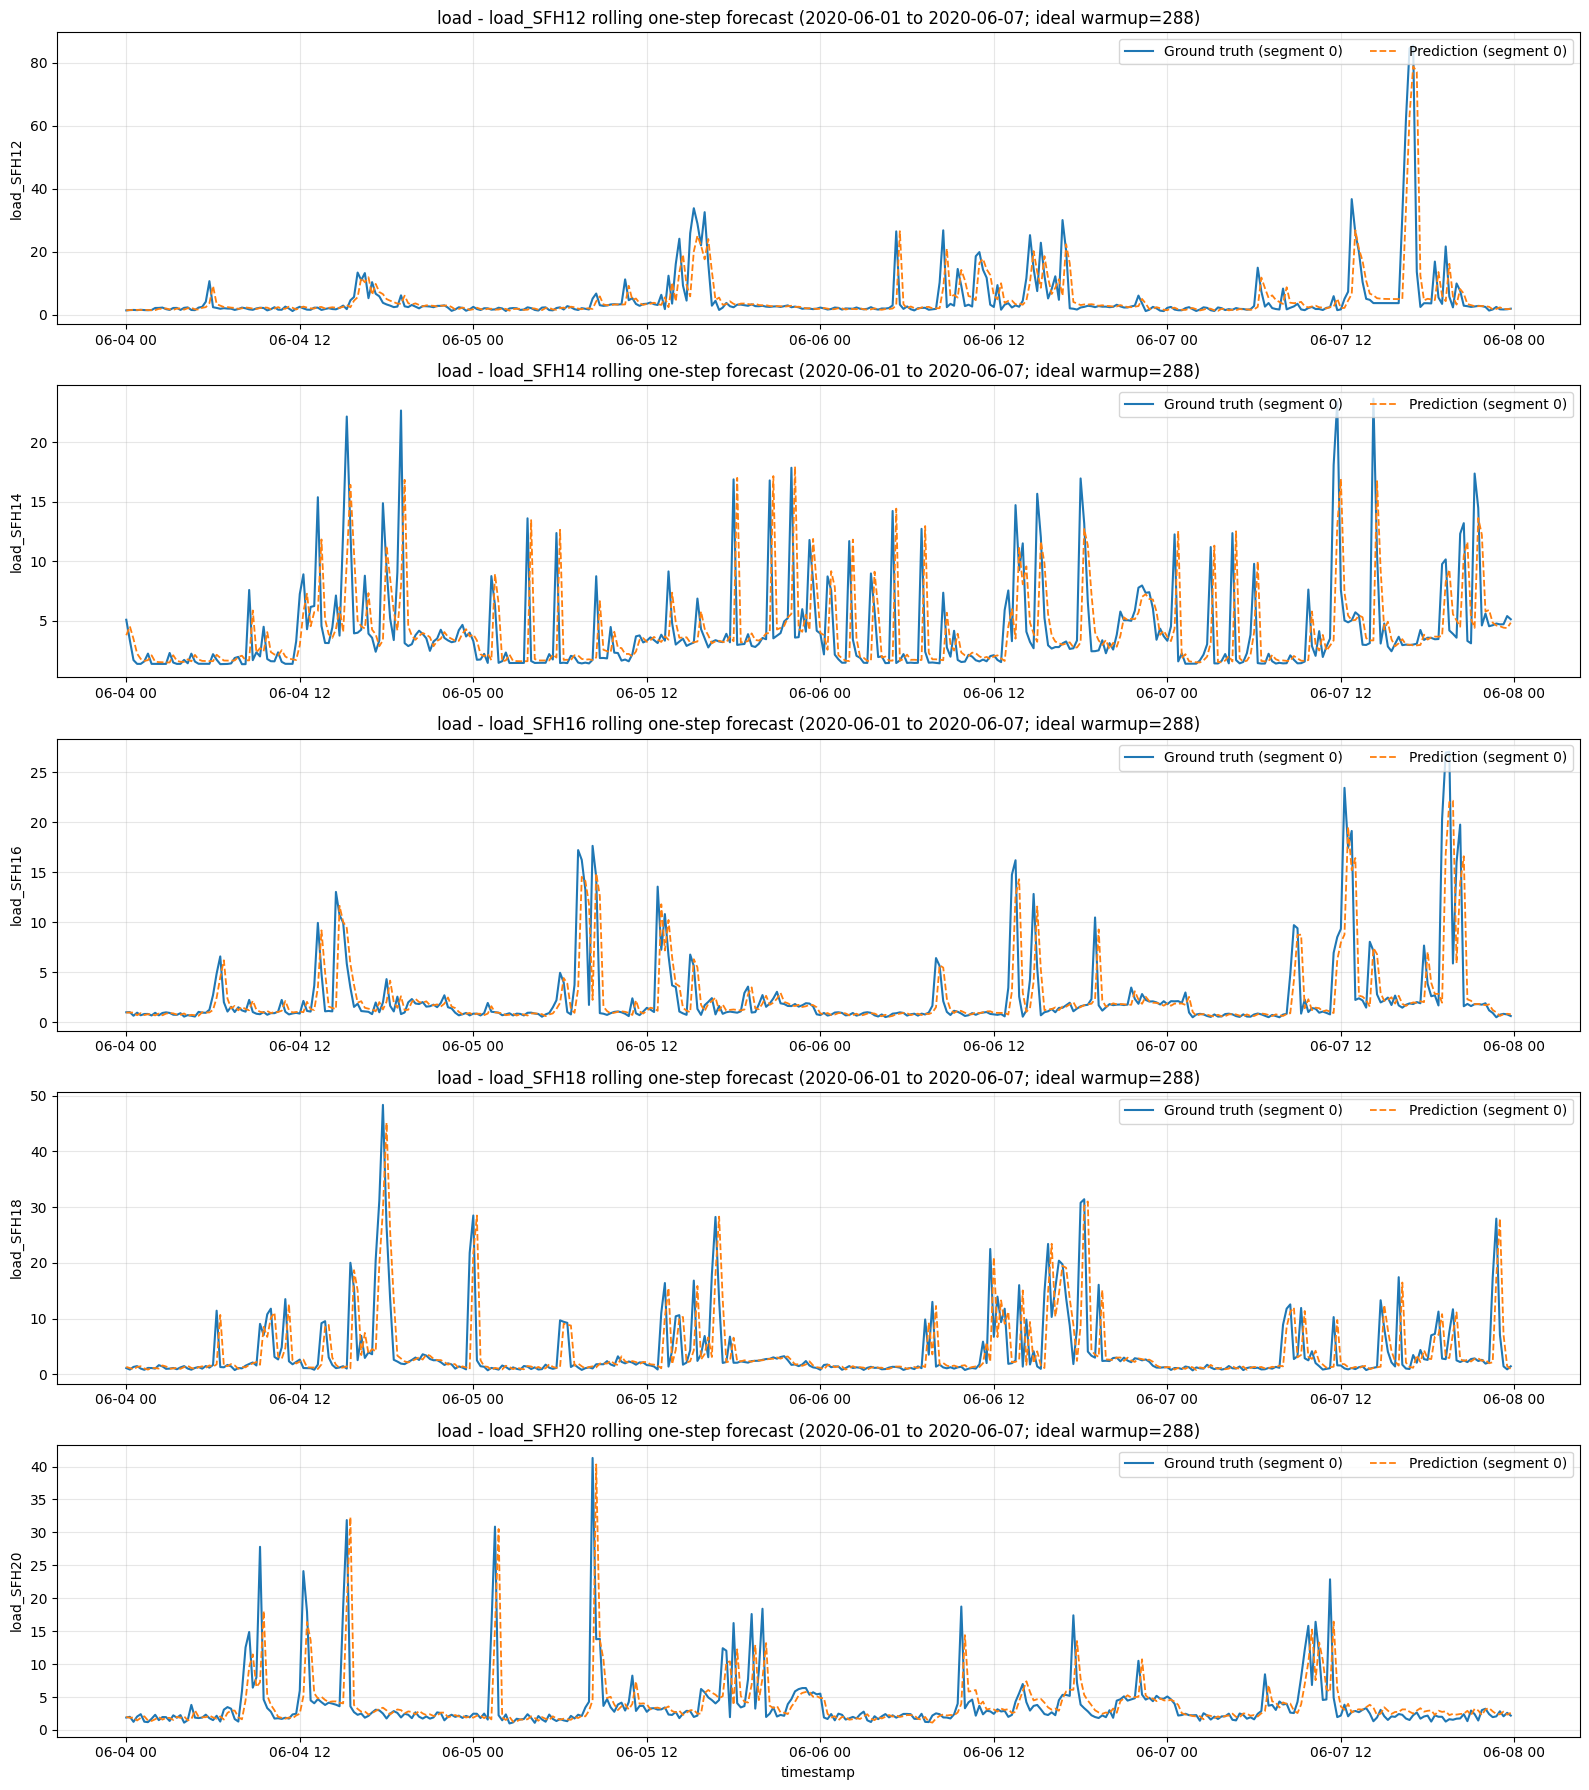

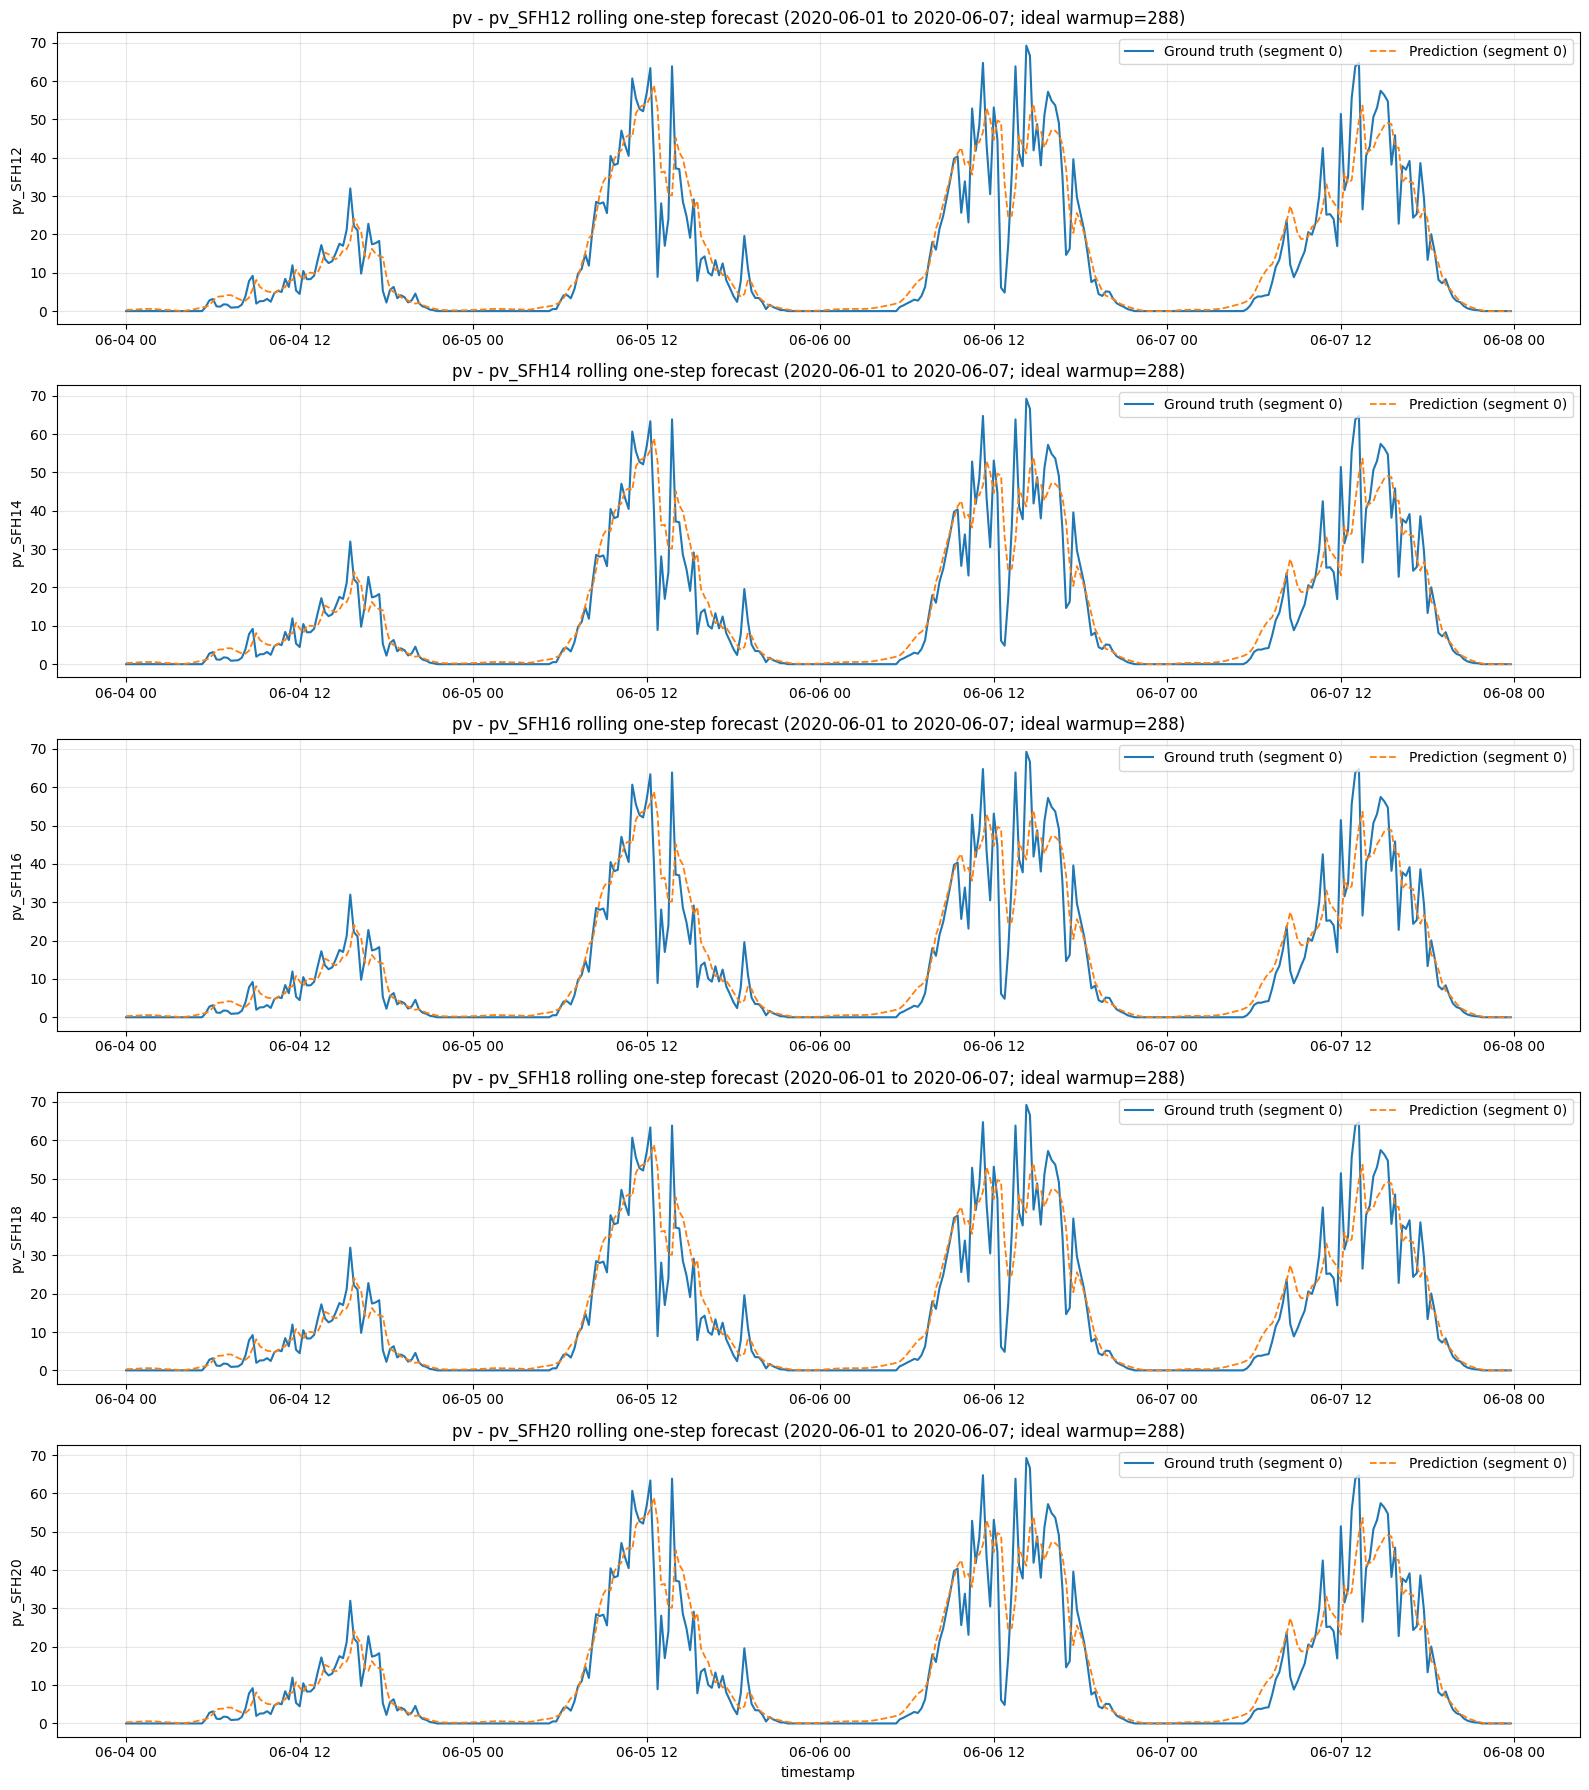

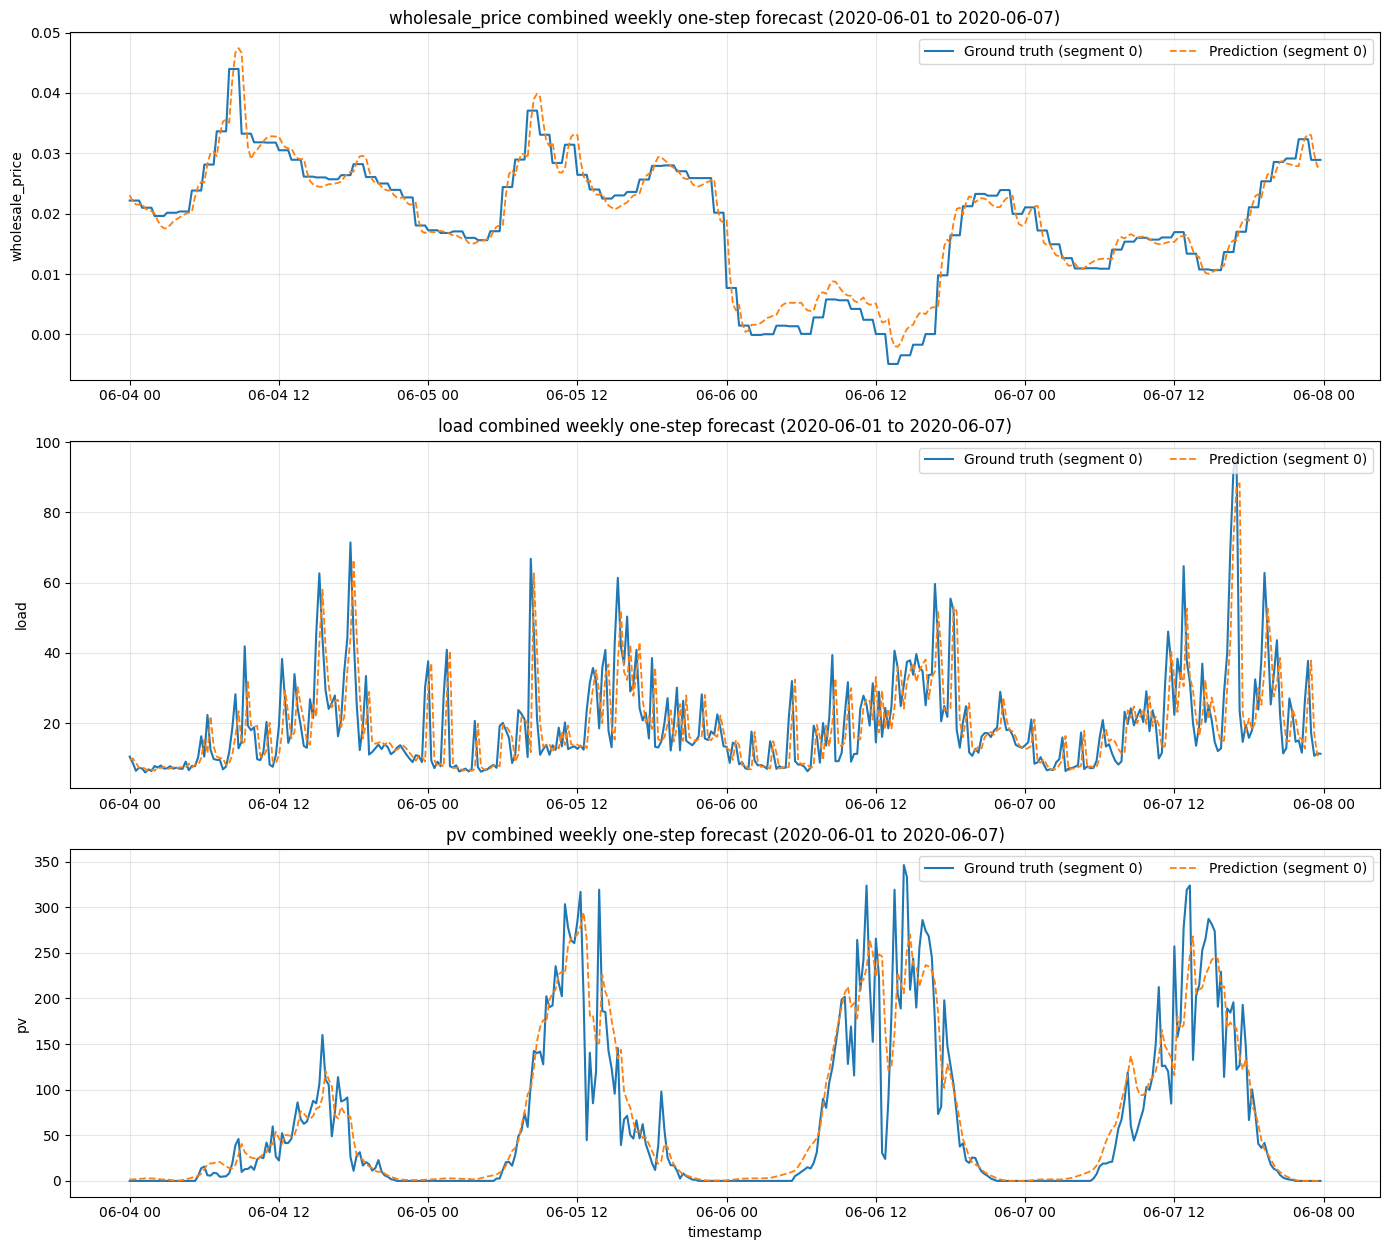

[section 3] validation bundle = C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\validation\lstm\h24\test_window_2020-06-01_2020-06-07


,signal_name,rmse,mae,mape_pct,row_count,segment_count,series_count
0,wholesale_price,0.002346,0.001690,329.413605,384,1,1
1,load,4.801977,2.126629,54.989414,1920,1,5
2,pv,7.321648,3.831169,58.264160,1920,1,5


{'window': {'start_date': '2020-06-01',
  'end_date': '2020-06-07',
  'label': '2020-06-01 to 2020-06-07'},
 'signal_order': ['wholesale_price', 'load', 'pv'],
 'bundle_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\validation\\lstm\\h24\\test_window_2020-06-01_2020-06-07',
 'signals': {'wholesale_price': {'segment_count': 1,
   'series_count': 1,
   'metrics': {'row_count': 384,
    'rmse': 0.0023464460391551256,
    'mae': 0.0016903574578464031,
    'mape_pct': 329.4136047363281},
   'per_series_metrics': {'wholesale_price': {'row_count': 384,
     'rmse': 0.0023464460391551256,
     'mae': 0.0016903574578464031,
     'mape_pct': 329.4136047363281}},
   'files': {'parquet': 'wholesale_price.parquet',
    'plot': 'wholesale_price_rolling.png'}},
  'load': {'segment_count': 1,
   'series_count': 5,
   'metrics': {'row_count': 1920,
    'rmse': 4.801977157592773,
    'mae': 2.12662935256958,
    'mape_pct': 54.98941421508789},
   'per_series_metrics': {

In [ ]:
from predictors.lstm_forecaster import LSTMForecaster
from predictors.training import _load_signal_matrix_from_source as load_signal_matrix_from_source, resolve_signal_physical_scale_from_source
from data.loaders.prosumer import ProsumerDataset


def _format_validation_window(start_date: str, end_date: str) -> str:
    return f"{start_date} to {end_date}"


def _build_local_date_mask(timestamps, *, start_date: str, end_date: str):
    start_local = pd.Timestamp(start_date).date()
    end_local = pd.Timestamp(end_date).date()
    timestamp_series = pd.Series(timestamps).reset_index(drop=True)
    local_dates = timestamp_series.apply(lambda value: pd.Timestamp(value).date())
    return ((local_dates >= start_local) & (local_dates <= end_local)).to_numpy(dtype=bool)


def _filter_frame_and_values_by_date_range(frame, values, *, signal_name: str, start_date: str, end_date: str):
    if 'timestamp' not in frame.columns:
        raise ValueError(f'signal={signal_name} does not expose a timestamp column, so weekly validation filtering is unavailable.')
    mask = _build_local_date_mask(frame['timestamp'], start_date=start_date, end_date=end_date)
    filtered_frame = frame.loc[mask].reset_index(drop=True)
    filtered_values = np.asarray(values, dtype=np.float32)[mask]
    if filtered_frame.empty:
        raise ValueError(f'signal={signal_name} has no test rows inside {_format_validation_window(start_date, end_date)}.')
    return filtered_frame, filtered_values


def _artifact_bundle_from_result(result):
    artifact_paths = result['artifact_paths']
    if isinstance(artifact_paths, dict):
        return {
            'model_path': str(artifact_paths['model_path']),
            'meta_path': str(artifact_paths['meta_path']),
            'scaler_path': str(artifact_paths['scaler_path']),
        }
    normalized_bundle = []
    for item in artifact_paths:
        if isinstance(item, dict):
            normalized_bundle.append((str(item['model_path']), str(item['meta_path']), str(item['scaler_path'])))
        else:
            model_path, meta_path, scaler_path = item
            normalized_bundle.append((str(model_path), str(meta_path), str(scaler_path)))
    return normalized_bundle


def _build_signal_forecaster_from_result(signal_name: str):
    artifact_bundle = _artifact_bundle_from_result(results[signal_name])
    if isinstance(artifact_bundle, dict):
        return LSTMForecaster.from_artifacts(
            model_path=artifact_bundle['model_path'],
            meta_path=artifact_bundle['meta_path'],
            scaler_path=artifact_bundle['scaler_path'],
            device=runtime_state.device,
            signal_name=signal_name,
        )
    return LSTMForecaster.from_signal_artifacts({signal_name: artifact_bundle}, device=runtime_state.device)


def _load_component_test_signals(*, start_date: str, end_date: str):
    data_dir = Path(cfg.data.data_dir or project_root / 'data')
    from predictors.training import _resolve_prosumer_dataset_kwargs

    dataset_kwargs = _resolve_prosumer_dataset_kwargs(cfg, data_dir, 'test')
    dataset = ProsumerDataset(**dataset_kwargs)
    mask = _build_local_date_mask(dataset._timestamps, start_date=start_date, end_date=end_date)
    comp_signals = {}
    for key, value in dataset._signals.items():
        if not key.startswith('load_'):
            continue
        comp_signals[key] = np.asarray(value, dtype=np.float32)[mask]
    return comp_signals


def _build_signal_episode_meta(signal_name: str, source):
    physical_scale = resolve_signal_physical_scale_from_source(source, signal_name, split='test')
    if physical_scale is None:
        return None
    scale_values = np.asarray(physical_scale, dtype=np.float32).reshape(-1).tolist()
    if signal_name == 'load':
        return {'load_scale': scale_values}
    if signal_name == 'pv':
        return {'pv_peak_kw': scale_values}
    return None


def _rolling_test_predictions_with_ideal_warmup(signal_name: str, *, start_date: str, end_date: str):
    source = results[signal_name]['source']
    test_frame, test_values, value_columns = load_signal_matrix_from_source(source, signal_name, split='test')
    test_frame, test_values = _filter_frame_and_values_by_date_range(
        test_frame,
        test_values,
        signal_name=signal_name,
        start_date=start_date,
        end_date=end_date,
    )
    forecaster = _build_signal_forecaster_from_result(signal_name)
    history_window = int(results[signal_name]['settings']['history_window'])
    has_component_runtimes = any(
        getattr(runtime, 'component', None) is not None
        for runtimes in forecaster.signal_runtimes.values()
        for runtime in runtimes
    )
    component_test_signals = None
    episode_meta = _build_signal_episode_meta(signal_name, source)
    if has_component_runtimes:
        component_test_signals = _load_component_test_signals(start_date=start_date, end_date=end_date)
    values = np.asarray(test_values, dtype=np.float32)
    if values.ndim == 1:
        values = values.reshape(-1, 1)
    working_frame = test_frame.copy()
    if 'segment_id' not in working_frame.columns:
        working_frame['segment_id'] = 0
    working_frame['segment_id'] = working_frame['segment_id'].fillna(0).astype(int)
    segment_views = []
    for segment_id in sorted(working_frame['segment_id'].unique()):
        segment_mask = working_frame['segment_id'] == segment_id
        segment_frame = working_frame.loc[segment_mask].reset_index(drop=True)
        segment_values = values[segment_mask.to_numpy()]
        if segment_values.shape[0] <= history_window:
            print(
                f"[skip] signal={signal_name}, segment_id={segment_id}: rows={segment_values.shape[0]} <= "
                f"history_window={history_window} within {_format_validation_window(start_date, end_date)}"
            )
            continue
        timestamps = []
        target_rows = []
        prediction_rows = []
        for end_idx in range(history_window, segment_values.shape[0]):
            history = segment_values[end_idx - history_window:end_idx]
            history_timestamps = segment_frame.iloc[end_idx - history_window:end_idx]['timestamp'].tolist()
            step_episode_signals = {}
            if has_component_runtimes:
                step_episode_signals = {
                    key: value[end_idx - history_window:end_idx]
                    for key, value in component_test_signals.items()
                }
            if step_episode_signals or episode_meta is not None:
                forecaster.set_episode(step_episode_signals, episode_meta=episode_meta)
            rollout = np.asarray(
                forecaster.predict(
                    history,
                    horizon=2,
                    signal_name=signal_name,
                    history_timestamps=history_timestamps,
                ),
                dtype=np.float32,
            )
            if rollout.ndim == 1:
                prediction_rows.append(np.array([rollout[1]], dtype=np.float32))
            else:
                prediction_rows.append(rollout[:, 1].astype(np.float32))
            target_rows.append(segment_values[end_idx].astype(np.float32))
            timestamps.append(segment_frame.iloc[end_idx]['timestamp'])
        segment_views.append(
            {
                'segment_id': int(segment_id),
                'timestamps': np.asarray(timestamps),
                'target': np.stack(target_rows, axis=0),
                'prediction': np.stack(prediction_rows, axis=0),
            }
        )
    if not segment_views:
        raise ValueError(
            f'signal={signal_name} has no test segment long enough for history_window={history_window} '
            f'within {_format_validation_window(start_date, end_date)}.'
        )
    return {
        'signal_name': signal_name,
        'segments': segment_views,
        'value_columns': list(value_columns),
        'history_window': history_window,
        'start_date': start_date,
        'end_date': end_date,
    }


def _plot_weekly_validation_signal(view, save_path: Path) -> Path:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    n_series = len(view['value_columns'])
    figure, axes = plt.subplots(n_series, 1, figsize=(16, 3.6 * n_series), sharex=False)
    axes = np.atleast_1d(axes)
    for user_idx, axis in enumerate(axes):
        user_name = view['value_columns'][user_idx]
        for segment in view['segments']:
            target_curve = segment['target'][:, user_idx]
            prediction_curve = segment['prediction'][:, user_idx]
            axis.plot(segment['timestamps'], target_curve, linewidth=1.5, label=f"Ground truth (segment {segment['segment_id']})")
            axis.plot(segment['timestamps'], prediction_curve, linewidth=1.3, linestyle='--', label=f"Prediction (segment {segment['segment_id']})")
        axis.set_title(
            f"{view['signal_name']} - {user_name} rolling one-step forecast "
            f"({ _format_validation_window(view['start_date'], view['end_date']) }; ideal warmup={view['history_window']})"
        )
        axis.set_ylabel(user_name)
        axis.grid(True, alpha=0.3)
        axis.legend(loc='upper right', ncol=2)
    axes[-1].set_xlabel('timestamp')
    figure.tight_layout()
    figure.savefig(save_path, dpi=150)
    plt.show()
    plt.close(figure)
    return save_path


def _plot_weekly_validation_combined(views, save_path: Path) -> Path:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    figure, axes = plt.subplots(len(views), 1, figsize=(14, 4.2 * len(views)), squeeze=False)
    for row_idx, view in enumerate(views):
        axis = axes[row_idx, 0]
        for segment in view['segments']:
            target_curve = segment['target'] if segment['target'].ndim == 1 else segment['target'].sum(axis=1)
            prediction_curve = segment['prediction'] if segment['prediction'].ndim == 1 else segment['prediction'].sum(axis=1)
            axis.plot(segment['timestamps'], target_curve, linewidth=1.5, label=f"Ground truth (segment {segment['segment_id']})")
            axis.plot(segment['timestamps'], prediction_curve, linewidth=1.3, linestyle='--', label=f"Prediction (segment {segment['segment_id']})")
        axis.set_title(
            f"{view['signal_name']} combined weekly one-step forecast "
            f"({ _format_validation_window(view['start_date'], view['end_date']) })"
        )
        axis.set_ylabel(view['signal_name'])
        axis.grid(True, alpha=0.3)
        axis.legend(loc='upper right', ncol=2)
    axes[-1, 0].set_xlabel('timestamp')
    figure.tight_layout()
    figure.savefig(save_path, dpi=150)
    plt.show()
    plt.close(figure)
    return save_path


def _flatten_weekly_validation_view(view) -> pd.DataFrame:
    rows = []
    for segment in view['segments']:
        timestamps = pd.to_datetime(segment['timestamps'], utc=True)
        for user_idx, series_name in enumerate(view['value_columns']):
            target_curve = np.asarray(segment['target'][:, user_idx], dtype=np.float64)
            prediction_curve = np.asarray(segment['prediction'][:, user_idx], dtype=np.float64)
            abs_error = np.abs(prediction_curve - target_curve)
            sq_error = np.square(prediction_curve - target_curve)
            denominator = np.where(np.abs(target_curve) > 1e-6, np.abs(target_curve), np.nan)
            ape = abs_error / denominator
            rows.append(
                pd.DataFrame(
                    {
                        'timestamp': timestamps,
                        'segment_id': int(segment['segment_id']),
                        'signal_name': view['signal_name'],
                        'series_name': str(series_name),
                        'target': target_curve.astype(np.float32),
                        'prediction': prediction_curve.astype(np.float32),
                        'abs_error': abs_error.astype(np.float32),
                        'sq_error': sq_error.astype(np.float32),
                        'ape': ape.astype(np.float32),
                    }
                )
            )
    if not rows:
        raise ValueError(f"signal={view['signal_name']} produced no validation rows.")
    return pd.concat(rows, ignore_index=True)


def _summarize_metric_frame(frame: pd.DataFrame) -> dict:
    rmse = float(np.sqrt(frame['sq_error'].mean()))
    mae = float(frame['abs_error'].mean())
    ape = frame['ape'].replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'row_count': int(len(frame)),
        'rmse': rmse,
        'mae': mae,
        'mape_pct': None if ape.empty else float(ape.mean() * 100.0),
    }


def _summarize_weekly_validation_frame(frame: pd.DataFrame) -> dict:
    per_series_metrics = {
        str(series_name): _summarize_metric_frame(series_frame)
        for series_name, series_frame in frame.groupby('series_name', sort=False)
    }
    return {
        'segment_count': int(frame['segment_id'].nunique()),
        'series_count': int(frame['series_name'].nunique()),
        'metrics': _summarize_metric_frame(frame),
        'per_series_metrics': per_series_metrics,
    }


def _json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    raise TypeError(f'Object of type {type(value).__name__} is not JSON serializable')


def _write_weekly_validation_bundle(views, bundle_dir: Path):
    bundle_dir = Path(bundle_dir)
    temp_dir = bundle_dir.with_name(f"{bundle_dir.name}.tmp.{uuid.uuid4().hex}")
    summary = {
        'window': {
            'start_date': weekly_validation_start_date,
            'end_date': weekly_validation_end_date,
            'label': _format_validation_window(weekly_validation_start_date, weekly_validation_end_date),
        },
        'signal_order': [view['signal_name'] for view in views],
        'bundle_dir': str(bundle_dir),
        'signals': {},
        'files': {},
        'created_at': pd.Timestamp.utcnow().isoformat(),
    }
    try:
        temp_dir.mkdir(parents=True, exist_ok=False)
        for view in views:
            signal_name = view['signal_name']
            validation_frame = _flatten_weekly_validation_view(view)
            parquet_name = f'{signal_name}.parquet'
            plot_name = f'{signal_name}_rolling.png'
            validation_frame.to_parquet(temp_dir / parquet_name, index=False)
            _plot_weekly_validation_signal(view, temp_dir / plot_name)
            signal_summary = _summarize_weekly_validation_frame(validation_frame)
            signal_summary['files'] = {
                'parquet': parquet_name,
                'plot': plot_name,
            }
            summary['signals'][signal_name] = signal_summary
        combined_plot_name = 'combined_weekly_validation.png'
        _plot_weekly_validation_combined(views, temp_dir / combined_plot_name)
        summary['files']['combined_plot'] = combined_plot_name
        (temp_dir / 'summary.json').write_text(json.dumps(summary, indent=2, default=_json_default), encoding='utf-8')
        if bundle_dir.exists():
            shutil.rmtree(bundle_dir, ignore_errors=True)
        temp_dir.replace(bundle_dir)
        return {'bundle_dir': bundle_dir, 'summary': summary}
    finally:
        if temp_dir.exists():
            shutil.rmtree(temp_dir, ignore_errors=True)


weekly_validation_views = [
    _rolling_test_predictions_with_ideal_warmup(
        signal_name,
        start_date=weekly_validation_start_date,
        end_date=weekly_validation_end_date,
    )
    for signal_name in weekly_validation_signals
]
weekly_validation_bundle = _write_weekly_validation_bundle(weekly_validation_views, weekly_validation_dir)
weekly_validation_summary = weekly_validation_bundle['summary']
weekly_metrics_table = pd.DataFrame(
    [
        {
            'signal_name': signal_name,
            'rmse': signal_summary['metrics']['rmse'],
            'mae': signal_summary['metrics']['mae'],
            'mape_pct': signal_summary['metrics']['mape_pct'],
            'row_count': signal_summary['metrics']['row_count'],
            'segment_count': signal_summary['segment_count'],
            'series_count': signal_summary['series_count'],
        }
        for signal_name, signal_summary in weekly_validation_summary['signals'].items()
    ]
)
print(f"[section 3] validation bundle = {weekly_validation_bundle['bundle_dir']}")
display(weekly_metrics_table)
weekly_validation_summary


## 4. Canonical MADRL Shared Data

After the weekly validation passes, clear stale packages under `artifacts/training/shared_data/mainline/` and regenerate the single canonical shared-data package for the `2019` training year and `2020` test year.

This notebook does not rebuild the historical full-year parquet handoff chain.


In [ ]:
shared_data_root.mkdir(parents=True, exist_ok=True)
stale_shared_data_dirs = sorted(path for path in shared_data_root.iterdir() if path.is_dir())
print(f'[section 4] shared_data_root = {shared_data_root.resolve()}')
if stale_shared_data_dirs:
    print('[section 4] removing stale shared-data directories:')
    for stale_dir in stale_shared_data_dirs:
        print(f' - {stale_dir.name}')
        shutil.rmtree(stale_dir, ignore_errors=True)
else:
    print('[section 4] no stale shared-data directories found.')
shared_data_result = ensure_madrl_shared_data(cfg, root=project_root)
remaining_shared_data_dirs = sorted(path.name for path in shared_data_root.iterdir() if path.is_dir())
shared_data_summary = {
    'shared_data_dir': str(shared_data_result.shared_data_dir),
    'signature_hash': str(shared_data_result.signature_hash),
    'reused': bool(shared_data_result.reused),
    'remaining_directories': remaining_shared_data_dirs,
    'train_split_episodes': int(shared_data_result.manifest['splits']['train']['num_episodes']),
    'test_split_episodes': int(shared_data_result.manifest['splits']['test']['num_episodes']),
    'schema_version': int(shared_data_result.manifest['schema_version']),
    'price_protocol_version': int(shared_data_result.manifest['price_protocol_version']),
}
pprint(shared_data_summary)
shared_data_result


[section 4] shared_data_root = C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\training\shared_data\mainline
[section 4] removing stale shared-data directories:
 - 68645c4de5784283


shared_data[train] episodes:   0%|          | 0/180 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Execution Check

This notebook is complete when:
1. section 2 trains `wholesale_price`, `load`, and `pv`
2. section 3 writes `artifacts/forecast/validation/lstm/h24/test_window_2020-06-01_2020-06-07/`
3. section 4 clears stale `artifacts/training/shared_data/mainline/*` directories and leaves exactly one new signature directory
4. no output path still points to the old `D:\GithubProject\MADRL_ESS` workspace
